# A Profitable Day Trading Strategy for the U.S. Equity Market

Reproduction of Zarattini, Barbon & Aziz, [*A Profitable Day Trading Strategy for the U.S. Equity Market*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4729284):
the 5-minute opening range breakout run across the whole U.S. stock universe,
January 2016 to December 2023.

This notebook covers the section 2.1 base strategy.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from firstrate_data import Store
from matplotlib.dates import DateFormatter, YearLocator
from matplotlib.ticker import FuncFormatter

from orb.engine import BacktestEngine
from orb.portfolio import Portfolio
from orb.results import buy_and_hold_balance
from orb.strategy import ORBStrategy

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)

# try running the strat on a subset of tickers first to see if it works.
FEW_TICKERS = (
    "AAPL",
    "MSFT",
    "NVDA",
    "AMD",
    "INTC",
    "CSCO",
    "ORCL",
    "AMZN",
    "TSLA",
    "NKE",
    "SBUX",
    "HD",
    "WMT",
    "TGT",
    "JPM",
    "BAC",
    "GS",
    "WFC",
    "JNJ",
    "PFE",
    "UNH",
    "MRK",
    "XOM",
    "CVX",
    "OXY",
    "BA",
    "CAT",
    "GE",
    "DIS",
    "NFLX",
)

The paper draws its universe from CRSP and its intraday bars from IQFeed. We read
FirstRate Data instead, whose stock dataset carries 11,000+ tickers over the
backtesting period against the roughly 7,000 the paper reports.

In [2]:
# pg 7
BACKTEST_START = date(2016, 1, 1)
BACKTEST_END = date(2023, 12, 31)
STARTING_BALANCE = 25_000.0

In [3]:
store = Store.from_env()

engine = BacktestEngine(
    store=store,
    strategy=ORBStrategy(opening_range_len_1_min_bars=5, daily_atr_percentage=0.10),
    portfolio=Portfolio(),
    # by leaving `tickers` commented out youll run the strategy on the full universe.
    # tickers=FEW_TICKERS,
    # tickers=("AAPL",),
    chunk_interval="3mo",
    start=BACKTEST_START,
    end=BACKTEST_END,
)
result = engine.run()
print("final balance:", engine.portfolio.balance)
result.elapsed_time

final balance: 31894.94255477543


datetime.timedelta(seconds=688, microseconds=223326)

In [4]:
result

BacktestResult(run_started=datetime.datetime(2026, 9, 9, 13, 9, 53, 491692, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')), run_finished=datetime.datetime(2026, 9, 9, 13, 21, 21, 715018, tzinfo=zoneinfo.ZoneInfo(key='America/New_York')), backtest_start=datetime.date(2016, 1, 1), backtest_end=datetime.date(2023, 12, 31), elapsed_time=datetime.timedelta(seconds=688, microseconds=223326), iterations=2048, total_orders=1383335, total_positions=1383335)

In [5]:
spy_buy_and_hold = buy_and_hold_balance(
    "SPY", BACKTEST_START, BACKTEST_END, STARTING_BALANCE, store
)

orb_portfolio_balance = (
    spy_buy_and_hold.select("session")
    .join(engine.portfolio.equity_curve(), on="session", how="left")
    .select(
        "session",
        balance=pl.col("balance").forward_fill().fill_null(STARTING_BALANCE),
    )
)

## Figure 3

The ORB portfolio against a buy & hold on the S&P 500.

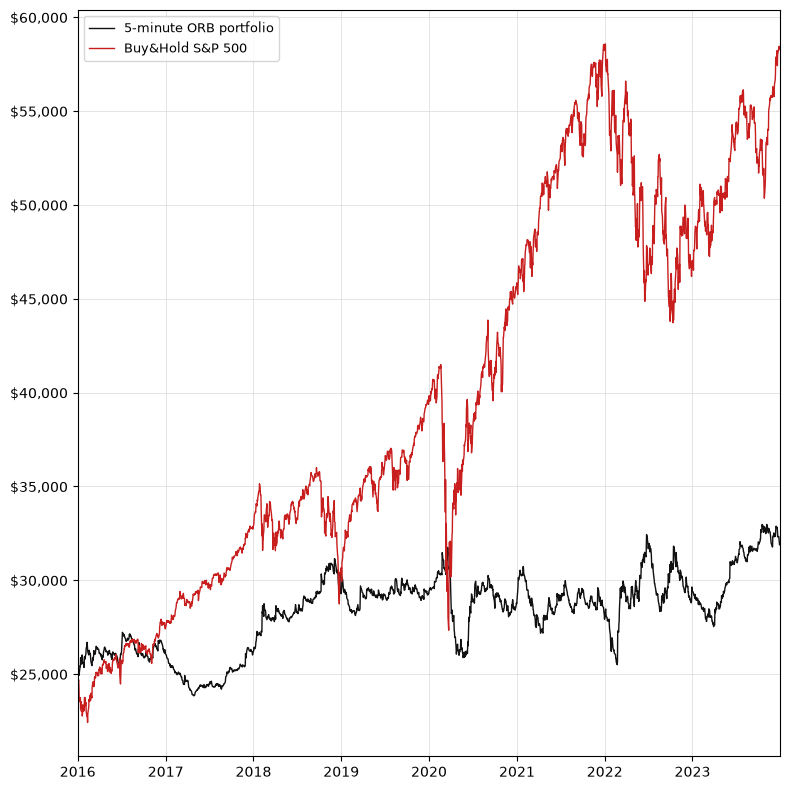

In [6]:
figure, axes = plt.subplots(figsize=(8, 8))

axes.plot(
    orb_portfolio_balance["session"],
    orb_portfolio_balance["balance"],
    color="#111111",
    linewidth=1,
    label="5-minute ORB portfolio",
)
axes.plot(
    spy_buy_and_hold["session"],
    spy_buy_and_hold["balance"],
    color="#c81e1e",
    linewidth=1,
    label="Buy&Hold S&P 500",
)

axes.yaxis.set_major_formatter(FuncFormatter(lambda balance, _: f"${balance:,.0f}"))
axes.set_xlim(BACKTEST_START, BACKTEST_END)
axes.xaxis.set_major_locator(YearLocator())
axes.xaxis.set_major_formatter(DateFormatter("%Y"))
axes.grid(color="0.85", linewidth=0.5)
axes.set_axisbelow(True)
axes.legend(loc="upper left", fontsize=9)

figure.tight_layout()
plt.show()

## Table 1

In [7]:
SESSIONS_A_YEAR = 252


def session_returns(balance: pl.Series) -> np.ndarray:
    curve = np.concatenate([[STARTING_BALANCE], balance.to_numpy()])
    return curve[1:] / curve[:-1] - 1


def measure_performance(
    balance: pl.Series, benchmark_returns: np.ndarray | None = None
) -> dict[str, float]:
    curve = np.concatenate([[STARTING_BALANCE], balance.to_numpy()])
    returns = session_returns(balance)
    growth = curve[-1] / curve[0]
    irr = growth ** (SESSIONS_A_YEAR / len(returns)) - 1
    volatility = returns.std(ddof=1) * np.sqrt(SESSIONS_A_YEAR)
    max_drawdown = -(curve / np.maximum.accumulate(curve) - 1).min()

    if benchmark_returns is None:
        beta, alpha_a_session = 1.0, 0.0
    else:
        beta, alpha_a_session = np.polyfit(benchmark_returns, returns, 1)

    return {
        "Total Return": growth - 1,
        "IRR": irr,
        "Volatility": volatility,
        "Sharpe Ratio": irr / volatility,
        "Hit Ratio": float((returns > 0).mean()),
        "MDD": max_drawdown,
        "Worst Day": returns.min(),
        "Alpha": alpha_a_session * SESSIONS_A_YEAR,
        "Beta": beta,
    }


spy_returns = session_returns(spy_buy_and_hold["balance"])

table_1 = pl.DataFrame(
    [
        {"Strategy": "ORB Base"}
        | measure_performance(orb_portfolio_balance["balance"], spy_returns),
        {"Strategy": "S&P500"} | measure_performance(spy_buy_and_hold["balance"]),
    ]
)
table_1


Strategy,Total Return,IRR,Volatility,Sharpe Ratio,Hit Ratio,MDD,Worst Day,Alpha,Beta
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ORB Base""",0.275798,0.030977,0.102257,0.302935,0.41004,0.19683,-0.025981,0.036642,-0.007761
"""S&P500""",1.331437,0.111845,0.184723,0.605475,0.545726,0.341047,-0.109424,0.0,1.0


In [8]:
PERCENT_COLUMNS = (
    "Total Return",
    "IRR",
    "Volatility",
    "Hit Ratio",
    "MDD",
    "Worst Day",
    "Alpha",
)

table_1_as_in_the_paper = table_1.with_columns(
    *[
        pl.col(column).map_elements(
            lambda share: f"{share:.1%}", return_dtype=pl.String
        )
        for column in PERCENT_COLUMNS
    ],
    *[
        pl.col(column).map_elements(
            lambda value: f"{value:.2f}", return_dtype=pl.String
        )
        for column in ("Sharpe Ratio", "Beta")
    ],
)
table_1_as_in_the_paper

Strategy,Total Return,IRR,Volatility,Sharpe Ratio,Hit Ratio,MDD,Worst Day,Alpha,Beta
str,str,str,str,str,str,str,str,str,str
"""ORB Base""","""27.6%""","""3.1%""","""10.2%""","""0.30""","""41.0%""","""19.7%""","""-2.6%""","""3.7%""","""-0.01"""
"""S&P500""","""133.1%""","""11.2%""","""18.5%""","""0.61""","""54.6%""","""34.1%""","""-10.9%""","""0.0%""","""1.00"""


In [11]:
paper_table_1 = pl.DataFrame(
    [
        {
            "Strategy": "ORB Base",
            "Total Return": "29%",
            "IRR": "3.2%",
            "Volatility": "6.6%",
            "Sharpe Ratio": "0.48",
            "Hit Ratio": "41.4%",
            "MDD": "13%",
            "Worst Day": "-0.8%",
            "Alpha": "3.3%",
            "Beta": "0.01",
        },
        {
            "Strategy": "S&P500",
            "Total Return": "198%",
            "IRR": "14.2%",
            "Volatility": "18.3%",
            "Sharpe Ratio": "0.78",
            "Hit Ratio": "54.9%",
            "MDD": "34%",
            "Worst Day": "-10.9%",
            "Alpha": "0.00%",
            "Beta": "1.00",
        },
    ]
)

pl.concat(
    [
        table_1_as_in_the_paper.with_columns(Source=pl.lit("notebook")),
        paper_table_1.with_columns(Source=pl.lit("paper")),
    ]
).sort("Strategy", "Source")

Strategy,Total Return,IRR,Volatility,Sharpe Ratio,Hit Ratio,MDD,Worst Day,Alpha,Beta,Source
str,str,str,str,str,str,str,str,str,str,str
"""ORB Base""","""27.6%""","""3.1%""","""10.2%""","""0.30""","""41.0%""","""19.7%""","""-2.6%""","""3.7%""","""-0.01""","""notebook"""
"""ORB Base""","""29%""","""3.2%""","""6.6%""","""0.48""","""41.4%""","""13%""","""-0.8%""","""3.3%""","""0.01""","""paper"""
"""S&P500""","""133.1%""","""11.2%""","""18.5%""","""0.61""","""54.6%""","""34.1%""","""-10.9%""","""0.0%""","""1.00""","""notebook"""
"""S&P500""","""198%""","""14.2%""","""18.3%""","""0.78""","""54.9%""","""34%""","""-10.9%""","""0.00%""","""1.00""","""paper"""


Total return, IRR, hit ratio, alpha and beta match the paper's figures. Our
portfolio is the more volatile of the two: 10.2% against 6.6%, a 19.7% drawdown
against 13%, and a worst day of -2.6% against -0.8%.

The benchmark row differs on return alone, 133% against 198%, while its
volatility, drawdown and worst day match. `buy_and_hold_balance` compounds
split-adjusted SPY closes and so ignores dividends; reinvesting them brings the
S&P 500 to roughly 170% over the period, still short of the paper's 198%.

## Not yet reproduced

The section 4 *Stocks in Play* refinement, which ranks the eligible stocks by the
relative volume of their first 5 minutes and trades only the top of that ranking.